In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# Encoder / Decoder (same conv stack shape as v2.ipynb)
# ---------------------------------------------------------------------------

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
        )

    def forward(self, x):
        return self.encoder(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(x)


# ---------------------------------------------------------------------------
# k-NN graph over samples (batch dimension), not over pixels/features
# ---------------------------------------------------------------------------

def build_knn_graph(z, k):
    """
    z : (n, d) embeddings, one row per sample in the batch.
    k : number of neighbours per sample.

    Returns knn_idx : (n, k) long tensor of neighbour indices.

    Detached / no_grad by design: the *choice* of neighbours is a discrete,
    non-differentiable operation (same stance the project plan takes for
    Track A — "fixed (detached) k-NN indices in, differentiable barycenter
    out"). Gradients still flow through the GAT layer's use of those
    neighbours' features.
    """
    n = z.shape[0]
    k = min(k, n - 1)  # guard against tiny batches
    with torch.no_grad():
        dist = torch.cdist(z, z)                      # (n, n)
        dist.fill_diagonal_(float("inf"))
        knn_idx = dist.topk(k, largest=False).indices  # (n, k)
    return knn_idx


# ---------------------------------------------------------------------------
# GAT layer over samples
# ---------------------------------------------------------------------------

class SampleGATLayer(nn.Module):
    """
    Multi-head Graph Attention layer (Velickovic et al., ICLR 2018),
    applied over samples-as-nodes with a fixed k-NN adjacency per forward
    pass.

    For node i with neighbours j in knn_idx[i]:
        h_i = W x_i
        e_ij = LeakyReLU(a_src . h_i + a_dst . h_j)
        alpha_ij = softmax_j(e_ij)
        out_i = sum_j alpha_ij * h_j          (heads concatenated or averaged)
    """

    def __init__(self, in_dim, out_dim, heads=4, dropout=0.1, concat=True):
        super().__init__()
        self.heads = heads
        self.out_dim = out_dim
        self.concat = concat

        self.W = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.a_src = nn.Parameter(torch.empty(1, 1, heads, out_dim))
        self.a_dst = nn.Parameter(torch.empty(1, 1, heads, out_dim))
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

        self.leaky_relu = nn.LeakyReLU(0.2)
        self.attn_dropout = nn.Dropout(dropout)

        self.out_proj = nn.Linear(heads * out_dim, out_dim) if concat else None

    def forward(self, z, knn_idx):
        """
        z       : (n, in_dim)
        knn_idx : (n, k)  neighbour indices per node (from build_knn_graph)
        returns : (n, out_dim)
        """
        n, k = knn_idx.shape
        h = self.W(z).view(n, self.heads, self.out_dim)   # (n, heads, d)

        h_dst = h[knn_idx]                                 # (n, k, heads, d)  neighbour features
        h_src = h.unsqueeze(1).expand(-1, k, -1, -1)        # (n, k, heads, d)  self, broadcast over k

        e = self.leaky_relu(
            (h_src * self.a_src).sum(-1) + (h_dst * self.a_dst).sum(-1)
        )                                                    # (n, k, heads)

        alpha = F.softmax(e, dim=1)                         # normalize over the k neighbours
        alpha = self.attn_dropout(alpha)

        out = (alpha.unsqueeze(-1) * h_dst).sum(dim=1)      # (n, heads, d)

        if self.concat:
            out = out.reshape(n, self.heads * self.out_dim)
            out = self.out_proj(out)
        else:
            out = out.mean(dim=1)
        return out


class SampleGAT(nn.Module):
    """Stack of SampleGATLayer blocks with residual connections + LayerNorm,
    playing the role of the "shift" step: it moves each sample's embedding
    toward a learned, attention-weighted combination of its k nearest
    neighbours' embeddings — the differentiable analogue of DMSL's
    density-weighted barycenter shift."""

    def __init__(self, dim, k=50, heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.k = k
        self.layers = nn.ModuleList([
            SampleGATLayer(dim, dim, heads=heads, dropout=dropout, concat=True)
            for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(dim) for _ in range(num_layers)])

    def forward(self, z):
        """z: (n, dim) flattened embeddings -> (n, dim) shifted embeddings."""
        h = z
        for layer, norm in zip(self.layers, self.norms):
            knn_idx = build_knn_graph(h.detach(), self.k)   # recompute graph on current embedding
            delta = layer(h, knn_idx)
            h = norm(h + F.elu(delta))                      # residual keeps this close to an
        return h                                            # identity-initialised shift early in training


# ---------------------------------------------------------------------------
# Full model: Encoder -> k-NN(50) -> GAT-over-samples -> Decoder
# ---------------------------------------------------------------------------

class EncoderKNNGATDecoder(nn.Module):
    def __init__(self, k=50, gat_heads=4, gat_layers=2, dropout=0.1, num_classes=10):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

        with torch.no_grad():
            probe = self.encoder(torch.zeros(1, 1, 28, 28))
        self.spatial_shape = probe.shape[1:]                # (C, H, W) e.g. (64, 1, 1)
        embed_dim = probe.flatten(1).shape[1]

        self.gat = SampleGAT(embed_dim, k=k, heads=gat_heads,
                              num_layers=gat_layers, dropout=dropout)
        # Classifier head
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        """
        x : (n, 1, 28, 28) batch of images.

        Returns
        -------
        x_recon   : (n, 1, 28, 28) reconstruction from decoder
        z         : (n, embed_dim) pre-shift embedding (encoder output, flattened)
        z_shifted : (n, embed_dim) post-GAT embedding
        logits    : (n, num_classes) classification logits
        """
        n = x.shape[0]
        z_spatial = self.encoder(x)                # (n, C, H, W)
        z = z_spatial.flatten(1)                    # (n, embed_dim)

        z_shifted = self.gat(z)                     # (n, embed_dim)

        # Classifier output
        logits = self.classifier(z_shifted)

        z_shifted_spatial = z_shifted.view(n, *self.spatial_shape)
        x_recon = self.decoder(z_shifted_spatial)

        return x_recon, z, z_shifted, logits


# ---------------------------------------------------------------------------
# Quick sanity check
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    torch.manual_seed(0)
    model = EncoderKNNGATDecoder(k=50, gat_heads=4, gat_layers=2)

    x = torch.randn(128, 1, 28, 28)  # batch > k so the k-NN graph is well-formed
    x_recon, z, z_shifted, logits = model(x)

    print("input        :", x.shape)
    print("embedding    :", z.shape)
    print("shifted      :", z_shifted.shape)
    print("reconstructed:", x_recon.shape)
    print("logits       :", logits.shape)

    # confirm gradients flow end-to-end through encoder -> GAT -> decoder -> classifier
    dummy_labels = torch.randint(0, 10, (x.shape[0],))
    reconstruction_loss = F.mse_loss(x_recon, torch.sigmoid(x))
    classification_loss = F.cross_entropy(logits, dummy_labels)
    total_loss = reconstruction_loss + classification_loss

    total_loss.backward()
    grad_norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
    print(f"backward OK, {len(grad_norms)} parameter tensors received gradients, "
          f"min/mean/max grad norm = {min(grad_norms):.4f}/"
          f"{sum(grad_norms)/len(grad_norms):.4f}/{max(grad_norms):.4f}")

input        : torch.Size([128, 1, 28, 28])
embedding    : torch.Size([128, 64])
shifted      : torch.Size([128, 64])
reconstructed: torch.Size([128, 1, 28, 28])
logits       : torch.Size([128, 10])
backward OK, 36 parameter tensors received gradients, min/mean/max grad norm = 0.0000/0.3944/2.3930


In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets

import matplotlib.pyplot as plt
from sklearn.decomposition import  PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from umap import  UMAP
import numpy as np

In [46]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=None, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=None, download=True)

In [47]:
train_dataset.data = (train_dataset.data.float() / 255.0 - 0.1307) / 0.3081
test_dataset.data = (test_dataset.data.float() / 255.0 - 0.1307) / 0.3083

In [48]:
def train(model, device, epochs=50):
    history = []

    model.to(device)
    data = train_dataset.data.to(device)
    data = data.unsqueeze(1)
    labels = train_dataset.targets.to(device)

    model.train()
    reconstruction = nn.MSELoss()
    classification = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        for i in range(0, 6):
          batch_data = data[i*10000:(i+1)*10000]
          batch_labels = labels[i*10000:(i+1)*10000]
          if batch_data.shape[0] == 0:
            continue
          if batch_labels.shape[0] == 0:
            continue

          optimizer.zero_grad()
          x_recon, z, z_shifted, logits = model(batch_data)
          loss = reconstruction(x_recon, torch.sigmoid(batch_data)) + classification(logits, batch_labels)

          loss.backward()
          optimizer.step()

        history.append(loss.item())
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | Full-Batch Loss: {loss.item():.4f}")

    return history

In [49]:
model = model.float()
history = train(model, "cuda", epochs=100)

Epoch 00 | Full-Batch Loss: 2.0017
Epoch 10 | Full-Batch Loss: 0.1837
Epoch 20 | Full-Batch Loss: 0.0965
Epoch 30 | Full-Batch Loss: 0.0677
Epoch 40 | Full-Batch Loss: 0.0494
Epoch 50 | Full-Batch Loss: 0.0334
Epoch 60 | Full-Batch Loss: 0.0252
Epoch 70 | Full-Batch Loss: 0.0194
Epoch 80 | Full-Batch Loss: 0.0177
Epoch 90 | Full-Batch Loss: 0.0120


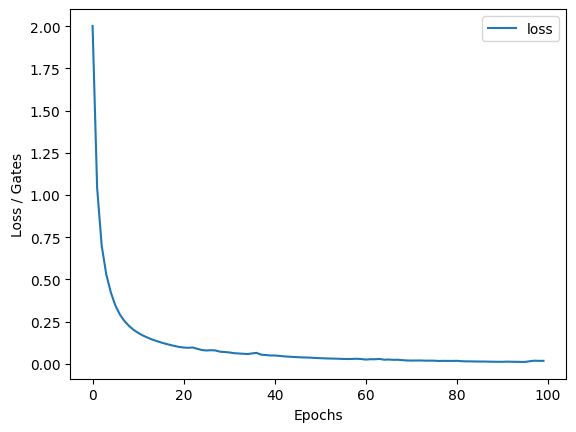

In [50]:
plt.plot(history, label="loss")
plt.xlabel('Epochs')
plt.ylabel('Loss / Gates')
plt.legend()
plt.show()

In [51]:
def visualize(model, device):
    model.to(device)

    train_data = train_dataset.data.to(device)
    train_data = train_data.unsqueeze(1)[:10000]
    test_data = test_dataset.data.to(device)
    test_data = test_data.unsqueeze(1)[:10000]

    model.eval()
    with torch.no_grad():
        # Get encoder outputs
        encoder_output_train = model.encoder(train_data)
        encoder_output_test = model.encoder(test_data)

        # Flatten encoder outputs to be (N, embed_dim) for GAT
        train_emb_before = encoder_output_train.flatten(start_dim=1)
        test_emb_before = encoder_output_test.flatten(start_dim=1)

        # Pass flattened embeddings through GAT
        train_emb_after = model.gat(train_emb_before)
        test_emb_after = model.gat(test_emb_before)

        # Convert to numpy for PCA/UMAP
        train_emb_before = train_emb_before.cpu().numpy()
        train_emb_after = train_emb_after.cpu().numpy()
        test_emb_before = test_emb_before.cpu().numpy()
        test_emb_after = test_emb_after.cpu().numpy()

    pca = PCA(n_components=2)
    train_pca_before = pca.fit_transform(train_emb_before)
    train_pca_after = pca.transform(train_emb_after)
    test_pca_before = pca.transform(test_emb_before)
    test_pca_after = pca.transform(test_emb_after)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_pca_before[:, 0], train_pca_before[:, 1], c=train_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    plt.title('Train PCA before DMSL')

    plt.subplot(1, 2, 2)
    sc1 = plt.scatter(test_pca_before[:, 0], test_pca_before[:, 1], c=test_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc1.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test PCA before DMSL')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_pca_after[:, 0], train_pca_after[:, 1], c=train_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    plt.title('Train PCA after DMSL')

    plt.subplot(1, 2, 2)
    sc1 = plt.scatter(test_pca_after[:, 0], test_pca_after[:, 1], c=test_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc1.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test PCA after DMSL')

    plt.tight_layout()
    plt.show()

    umap = UMAP(n_components=2)
    train_umap_before = umap.fit_transform(train_emb_before)
    train_umap_after = umap.transform(train_emb_after)
    test_umap_before = umap.transform(test_emb_before)
    test_umap_after = umap.transform(test_emb_after)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_umap_before[:, 0], train_umap_before[:, 1], c=train_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    plt.title('Train UMAP before DMSL')

    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(test_umap_before[:, 0], test_umap_before[:, 1], c=test_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc2.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test UMAP before DMSL')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_umap_after[:, 0], train_umap_after[:, 1], c=train_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    plt.title('Train UMAP after DMSL')

    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(test_umap_after[:, 0], test_umap_after[:, 1], c=test_dataset.targets[:10000], cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc2.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test UMAP after DMSL')

    plt.tight_layout()
    plt.show()

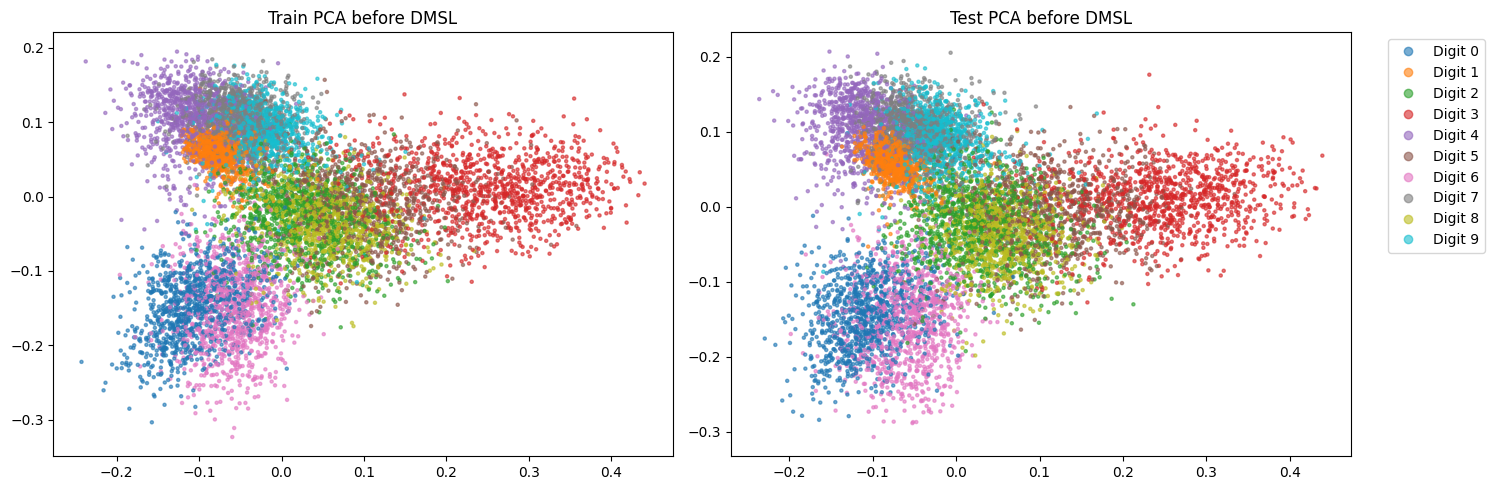

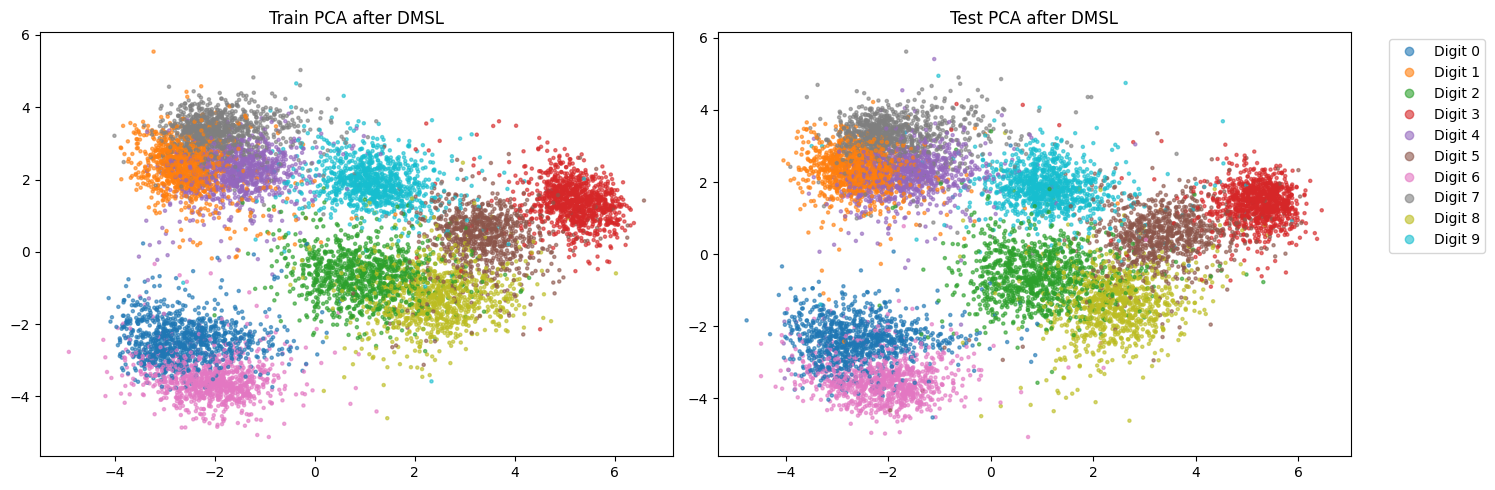

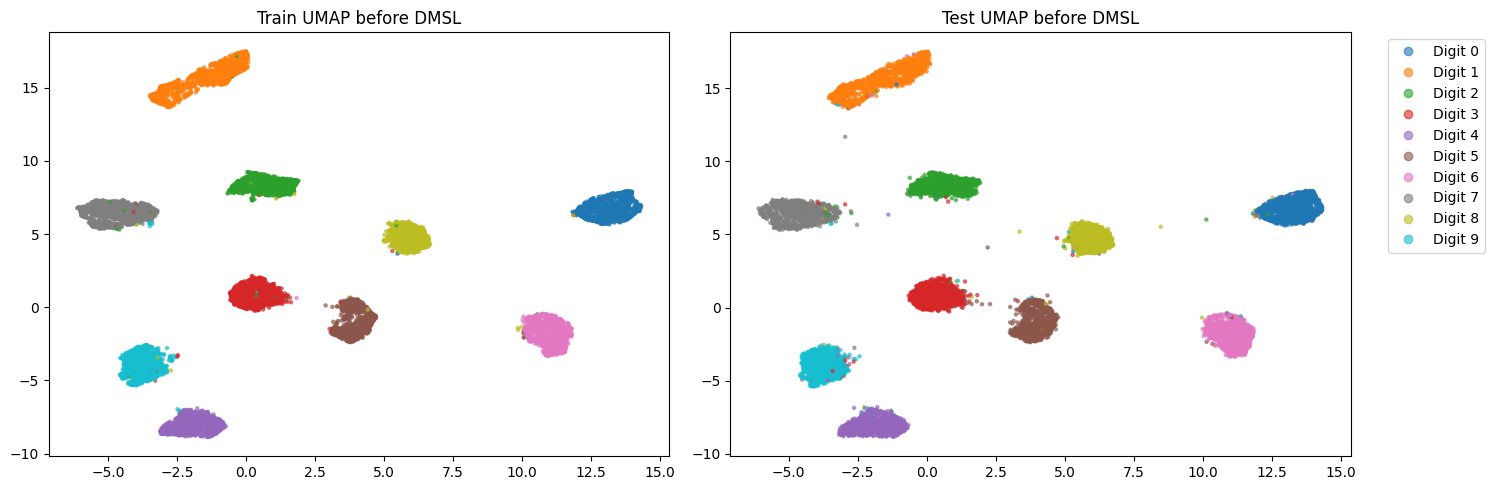

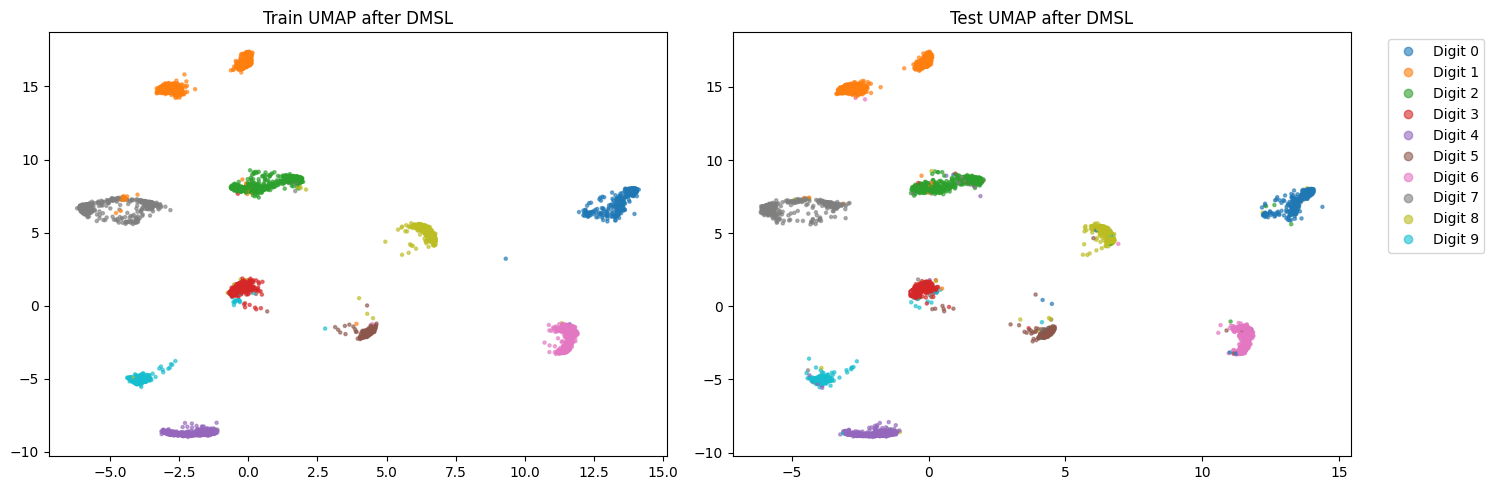

In [52]:
visualize(model, "cuda")

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [55]:
model.eval()
with torch.no_grad():
    test_data = test_dataset.data.to(device).unsqueeze(1)
    test_labels = test_dataset.targets.to(device)

    # Get predictions from the model
    x_recon, z, z_shifted, logits = model(test_data)

    # Convert logits to predicted classes
    pred_labels = torch.argmax(logits, dim=1)

    # Calculate accuracy
    accuracy = accuracy_score(test_labels.cpu().numpy(), pred_labels.cpu().numpy())
    print(f"Test Classification Accuracy: {accuracy:.4f}")

Test Classification Accuracy: 0.9818


### KNN Classification on Embeddings

In [58]:
model.eval()
with torch.no_grad():
    # Use a subset for consistency with visualization and memory constraints
    subset_size = 10000

    train_data_subset = train_dataset.data.to(device).unsqueeze(1)[:subset_size]
    train_labels_subset = train_dataset.targets[:subset_size]
    test_data_subset = test_dataset.data.to(device).unsqueeze(1)[:subset_size]
    test_labels_subset = test_dataset.targets[:subset_size]

    # Get encoder outputs
    encoder_output_train = model.encoder(train_data_subset)
    encoder_output_test = model.encoder(test_data_subset)

    # Flatten encoder outputs (before GAT)
    train_emb_before = encoder_output_train.flatten(start_dim=1).cpu().numpy()
    test_emb_before = encoder_output_test.flatten(start_dim=1).cpu().numpy()

    # Pass flattened embeddings through GAT (after GAT)
    train_emb_after = model.gat(torch.from_numpy(train_emb_before).to(device)).cpu().numpy()
    test_emb_after = model.gat(torch.from_numpy(test_emb_before).to(device)).cpu().numpy()

    # KNN on embeddings before GAT
    knn_before = KNeighborsClassifier(n_neighbors=5t)
    knn_before.fit(train_emb_before, train_labels_subset)
    preds_before = knn_before.predict(test_emb_before)
    accuracy_before = accuracy_score(test_labels_subset, preds_before)
    print(f"KNN Accuracy (Encoder Embeddings - Before GAT): {accuracy_before:.4f}")

    # KNN on embeddings after GAT
    knn_after = KNeighborsClassifier(n_neighbors=5)
    knn_after.fit(train_emb_after, train_labels_subset)
    preds_after = knn_after.predict(test_emb_after)
    accuracy_after = accuracy_score(test_labels_subset, preds_after)
    print(f"KNN Accuracy (GAT Embeddings - After GAT): {accuracy_after:.4f}")

KNN Accuracy (Encoder Embeddings - Before GAT): 0.9801
KNN Accuracy (GAT Embeddings - After GAT): 0.9821
